### 1: Mengimpor Pustaka (Libraries)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka Machine Learning XGBoost & Evaluasi
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, f1_score)

import warnings
warnings.filterwarnings('ignore')

print("Semua pustaka XGBoost dan Evaluasi berhasil dimuat!")

Semua pustaka XGBoost dan Evaluasi berhasil dimuat!


### 2: Memuat Data Hasil Optimasi GA (Single Source of Truth)

In [3]:
# Memuat data hasil optimasi algoritma genetika (Fase 2)
df = pd.read_csv('../dataset/processed/ga_optimized_features_dataset.csv')

# Memisahkan matriks fitur (X) dan target (y)
X = df.drop(columns=['label'])
y = df['label']

print(f"Dimensi Fitur (X): {X.shape}")
print(f"Dimensi Target (y): {y.shape}")

Dimensi Fitur (X): (638564, 51)
Dimensi Target (y): (638564,)


### 3: Pembagian Data yang Terisolasi (Train-Test Split)

In [4]:
# Pembagian 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah Data Pelatihan: {X_train.shape[0]} baris")
print(f"Jumlah Data Pengujian: {X_test.shape[0]} baris (Unseen Data)")

Jumlah Data Pelatihan: 510851 baris
Jumlah Data Pengujian: 127713 baris (Unseen Data)


### 4: Kalkulasi Penalti Imbalance & Konfigurasi Cross-Validation

In [5]:
# Menghitung rasio kelas 0 (Benign) terhadap kelas 1 (Malicious)
# Formula: total_negative / total_positive
count_class_0 = (y_train == 0).sum()
count_class_1 = (y_train == 1).sum()
imbalance_ratio = count_class_0 / count_class_1

print(f"Distribusi Kelas Pelatihan: {count_class_0} Benign vs {count_class_1} Malicious")
print(f"Nilai scale_pos_weight yang disuntikkan: {imbalance_ratio:.2f}")

# Inisialisasi Model XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio, # Mitigasi Cost-Sensitive Learning
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1 # Memaksimalkan core CPU di Ubuntu WSL 2
)

# Menyiapkan 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Distribusi Kelas Pelatihan: 341098 Benign vs 169753 Malicious
Nilai scale_pos_weight yang disuntikkan: 2.01


### 5: Eksekusi Stratified 5-Fold Cross-Validation

In [6]:
print("⏳ Menjalankan Stratified 5-Fold Cross Validation untuk XGBoost...")

# Menjalankan evaluasi silang
cv_results = cross_validate(
    xgb_model, X_train, y_train, cv=cv,
    scoring={'f1_macro': 'f1_macro', 'recall': 'recall'},
    n_jobs=-1
)

# Mengekstrak hasil
f1_mean = cv_results['test_f1_macro'].mean()
f1_std = cv_results['test_f1_macro'].std()
recall_mean = cv_results['test_recall'].mean()
recall_std = cv_results['test_recall'].std()

print("\n=== HASIL 5-FOLD CROSS-VALIDATION PADA DATA TRAINING (XGBOOST) ===")
print(f"F1-Macro Score : {f1_mean:.4f} (± {f1_std:.4f})")
print(f"Recall (Deteksi): {recall_mean:.4f} (± {recall_std:.4f})")
print("Catatan: Bandingkan angka stabilitas (±) ini dengan hasil Random Forest sebelumnya.")

⏳ Menjalankan Stratified 5-Fold Cross Validation untuk XGBoost...

=== HASIL 5-FOLD CROSS-VALIDATION PADA DATA TRAINING (XGBOOST) ===
F1-Macro Score : 0.9222 (± 0.0012)
Recall (Deteksi): 0.8920 (± 0.0016)
Catatan: Bandingkan angka stabilitas (±) ini dengan hasil Random Forest sebelumnya.


### 6: Pelatihan Akhir & Prediksi pada Data Unseen

In [7]:
print("⏳ Melatih XGBoost pada keseluruhan data training...")
xgb_model.fit(X_train, y_train)

print("🔍 Melakukan prediksi pada data pengujian (Testing Set)...")
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("✅ Prediksi selesai!")

⏳ Melatih XGBoost pada keseluruhan data training...
🔍 Melakukan prediksi pada data pengujian (Testing Set)...
✅ Prediksi selesai!


### 7: Visualisasi Siber (Confusion Matrix, ROC & Feature Importance)

=== CLASSIFICATION REPORT (XGBOOST) ===
              precision    recall  f1-score   support

      Benign       0.95      0.95      0.95     85275
   Malicious       0.90      0.89      0.90     42438

    accuracy                           0.93    127713
   macro avg       0.92      0.92      0.92    127713
weighted avg       0.93      0.93      0.93    127713



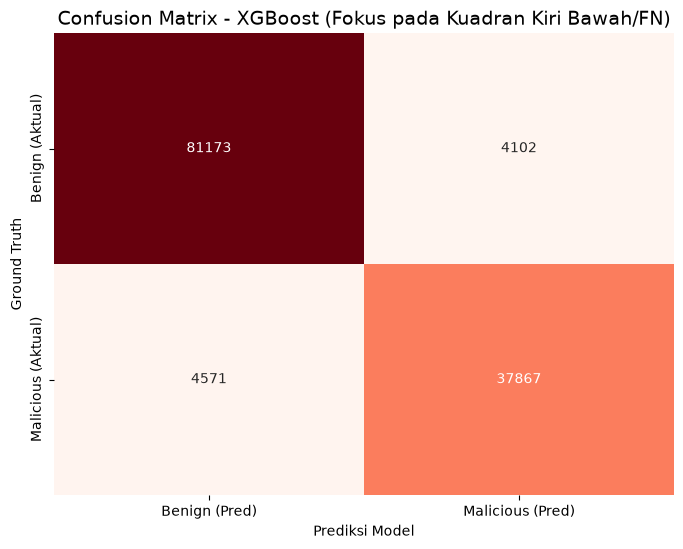

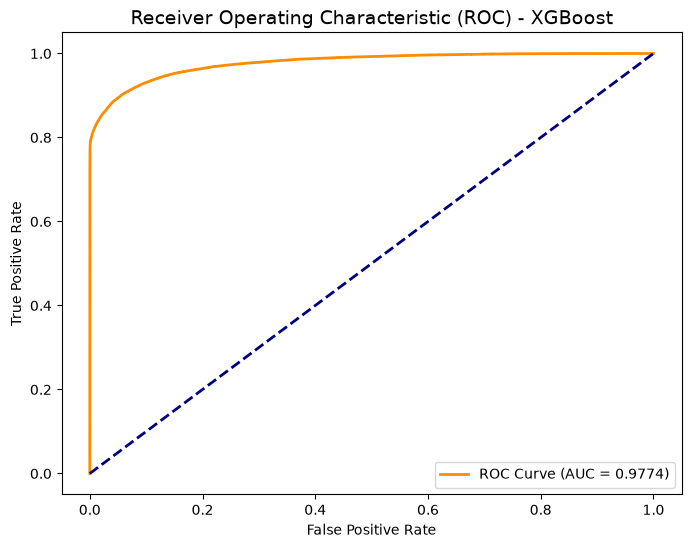

<Figure size 1000x800 with 0 Axes>

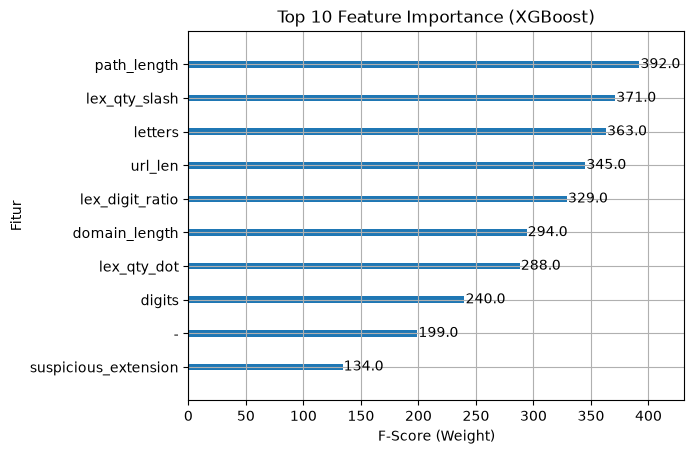

In [8]:
# 1. Classification Report
print("=== CLASSIFICATION REPORT (XGBOOST) ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Benign (Pred)', 'Malicious (Pred)'],
            yticklabels=['Benign (Aktual)', 'Malicious (Aktual)'])
plt.title('Confusion Matrix - XGBoost (Fokus pada Kuadran Kiri Bawah/FN)', fontsize=14)
plt.ylabel('Ground Truth')
plt.xlabel('Prediksi Model')
plt.show()

# 3. ROC-AUC Curve
roc_auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) - XGBoost', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# 4. Top 10 Feature Importance (XGBoost Built-in)
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight', 
                    title='Top 10 Feature Importance (XGBoost)',
                    xlabel='F-Score (Weight)', ylabel='Fitur')
plt.show()